##In this file we have performed extreme event analysis for the bias corrected TRMM data using ETCCDI Indices

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.ma as ma
import tensorflow as tf

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path='/content/drive/My Drive/Work7_MAUNet_Light_Data_Model_Result'
Label_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_Label_Test_TRMMIMD.npy')

In [6]:
datamask=np.load(path+"/Data/Mask-TRMM128x128.npy")

In [7]:
MAUNet_Light_KR_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_KR_TRMMIMD_TestResult.npy')

In [9]:
testmask=[]
for i in range(len(Label_Test_Grid)):
  testmask.append(datamask)
testmask=np.array(testmask)

In [10]:
Masked_Label_Test_Grid=ma.masked_array(Label_Test_Grid, mask=testmask)
Masked_MAUNet_Light_KR_Test_Grid=ma.masked_array(MAUNet_Light_KR_Test_Grid, mask=testmask)

#Consecutive Dry Day Calculation

In [11]:
import numpy as np

def max_consecutive_days_3d(arr):
    """
    arr shape: (610, 128, 128)
    output shape: (5, 128, 128)
    """
    days_per_year = 122
    num_years = 5

    # Output container
    result = np.zeros((num_years, arr.shape[1], arr.shape[2]), dtype=int)

    # Process year-by-year
    for y in range(num_years):
        # Extract year data → shape: (122, 128, 128)
        year_data = arr[y*days_per_year : (y+1)*days_per_year]

        # Boolean mask: True where value < 1
        mask = (year_data < 1)

        # Now compute maximum consecutive Trues along axis=0 (time axis)
        # Efficient algorithm:
        max_run = np.zeros((128, 128), dtype=int)
        current_run = np.zeros((128, 128), dtype=int)

        for t in range(days_per_year):
            # Increase run count where mask is True, reset to 0 otherwise
            current_run = (current_run + 1) * mask[t]
            max_run = np.maximum(max_run, current_run)

        result[y] = max_run

    return result

In [12]:
import numpy as np

CDD_Inter_Annual_GT = np.mean(max_consecutive_days_3d(Label_Test_Grid),axis=0)
CDD_Inter_Annual_MAUNet_Light_KR = np.mean(max_consecutive_days_3d(MAUNet_Light_KR_Test_Grid),axis=0)
#mask_cdd
Masked_CDD_Inter_Annual_GT = ma.masked_array(CDD_Inter_Annual_GT, mask=datamask)
Masked_CDD_Inter_Annual_MAUNet_Light_KR = ma.masked_array(CDD_Inter_Annual_MAUNet_Light_KR, mask=datamask)


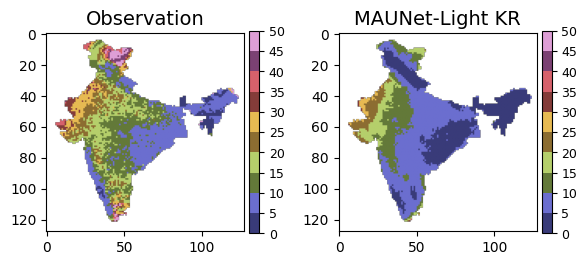

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

# ---- DATA + TITLES ----
data_list = [
    Masked_CDD_Inter_Annual_GT,
    Masked_CDD_Inter_Annual_MAUNet_Light_KR ]

titles = [
    "Observation",
    "MAUNet-Light KR" ]

# ------------------------------------------------------
# FIXED COLOR RANGE (bins)
# ------------------------------------------------------
bounds = [0,5,10,15,20,25,30,35,40,45,50]
cmap = plt.get_cmap("tab20b")
norm = BoundaryNorm(bounds, cmap.N)

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes = axes.flatten()

for i in range(2):
    im = axes[i].imshow(data_list[i], cmap=cmap, norm=norm)
    axes[i].set_title(titles[i], fontsize=14)

    # Use single consistent color boundaries
    cbar = plt.colorbar(im, ax=axes[i], shrink=0.75, pad=0.02)
    cbar.set_ticks(bounds)
    cbar.ax.tick_params(labelsize=9)

# Hide empty subplot
#axes[-1].axis("off")

plt.tight_layout()
plt.show()


##Count number of days per year where value > 20 at each grid cell.


In [19]:
import numpy as np

def extreme_threshold(arr):
    """
    Count number of days per year where value > 20 at each grid cell.

    Parameters
    ----------
    arr : np.ndarray
        Input array of shape (610, 128, 128)

    Returns
    -------
    result_th : np.ndarray
        Output array of shape (5, 128, 128)
    """
    days_per_year = 122
    num_years = 5
    H, W = arr.shape[1], arr.shape[2]

    # Initialize output
    result_th = np.zeros((num_years, H, W), dtype=int)

    # Process year by year
    for y in range(num_years):
        start = y * days_per_year
        end = start + days_per_year

        year_data = arr[start:end]           # shape: (122, 128, 128)

        # Count days where value > 20 along time axis (axis=0)
        count = np.sum(year_data > 20, axis=0)

        result_th[y] = count

    return result_th


In [20]:
import numpy.ma as ma

# -----------------------------
# Compute extreme day counts (>20) per year
# -----------------------------
Extreme_th_GT = np.mean(extreme_threshold(Label_Test_Grid), axis=0)
Extreme_th_MAUNet_Light_KR = np.mean(extreme_threshold(MAUNet_Light_KR_Test_Grid), axis=0)

# -----------------------------
# Apply mask
# -----------------------------
Masked_Extreme_th_GT = ma.masked_array(Extreme_th_GT, mask=datamask)
Masked_Extreme_th_MAUNet_Light_KR = ma.masked_array(Extreme_th_MAUNet_Light_KR, mask=datamask)


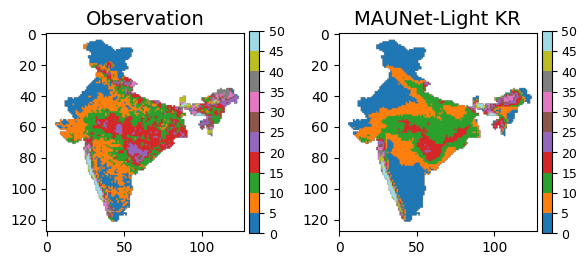

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

# -----------------------------
# List of masked extreme threshold arrays
# -----------------------------
data_list = [
    Masked_Extreme_th_GT,
    Masked_Extreme_th_MAUNet_Light_KR,
   ]

titles = [
    "Observation",
    "MAUNet-Light KR",
  ]

# -----------------------------
# Define color levels and norm
# -----------------------------
bounds = [0,5, 10,15, 20,25, 30,35,40,45,50]          # change as needed
cmap = plt.get_cmap("tab20")        # qualitative colormap
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes = axes.flatten()

for i in range(2):
    im = axes[i].imshow(data_list[i], cmap=cmap, norm=norm)
    axes[i].set_title(titles[i], fontsize=14)
    #axes[i].axis("off")

    # Colorbar for each subplot (optional: can do a shared colorbar if preferred)
    cbar = plt.colorbar(im, ax=axes[i], shrink=0.75, pad=0.02)
    cbar.set_ticks(bounds)
    cbar.ax.tick_params(labelsize=9)

# Hide 8th empty subplot
#axes[-1].axis("off")

plt.tight_layout()
plt.show()



##Find maximum rainfall value at each grid.

In [22]:
import numpy as np

def max_rainfall_per_year(arr):
    """
    Find maximum rainfall value at each grid for each year.

    Parameters
    ----------
    arr : np.ndarray
        Input array of shape (610, 128, 128)

    Returns
    -------
    result_max : np.ndarray
        Output array of shape (5, 128, 128)
        Each entry is the maximum rainfall at that grid for the year.
    """
    days_per_year = 122
    num_years = 5
    H, W = arr.shape[1], arr.shape[2]

    # Initialize output
    result_max = np.zeros((num_years, H, W), dtype=arr.dtype)

    # Process year by year
    for y in range(num_years):
        start = y * days_per_year
        end = start + days_per_year

        year_data = arr[start:end]  # shape: (122, 128, 128)

        # Find max along time axis (axis=0)
        max_vals = np.max(year_data, axis=0)

        result_max[y] = max_vals

    return result_max


In [23]:
import numpy.ma as ma

# -----------------------------
# Compute maximum rainfall per year and inter-annual mean
# -----------------------------
MaxRain_GT = np.mean(max_rainfall_per_year(Label_Test_Grid), axis=0)
MaxRain_MAUNet_Light_KR = np.mean(max_rainfall_per_year(MAUNet_Light_KR_Test_Grid), axis=0)

# -----------------------------
# Apply mask
# -----------------------------
Masked_MaxRain_GT = ma.masked_array(MaxRain_GT, mask=datamask)
Masked_MaxRain_MAUNet_Light_KR = ma.masked_array(MaxRain_MAUNet_Light_KR, mask=datamask)


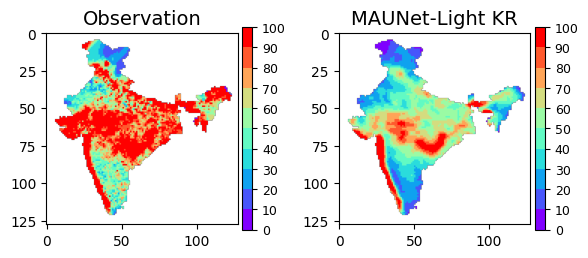

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

# -----------------------------
# List of masked maximum rainfall arrays
# -----------------------------
data_list = [
    Masked_MaxRain_GT,
    Masked_MaxRain_MAUNet_Light_KR,
]

titles = [
    "Observation",
    "MAUNet-Light KR",
]

# -----------------------------
# Define color levels and norm (adjust levels as needed)
# -----------------------------
bounds = [0,10,20,30,40,50,60,70,80,90,100]
#bounds= [0,20,40,60,80,100]         # example color levels, adjust based on max rainfall
cmap = plt.get_cmap("rainbow")        # qualitative colormap
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes = axes.flatten()

for i in range(2):
    im = axes[i].imshow(data_list[i], cmap=cmap, norm=norm)
    axes[i].set_title(titles[i], fontsize=14)
    #axes[i].axis("off")

    # Colorbar for each subplot
    cbar = plt.colorbar(im, ax=axes[i], shrink=0.75, pad=0.02)
    cbar.set_ticks(bounds)
    cbar.ax.tick_params(labelsize=9)

# Hide 8th empty subplot
#axes[-1].axis("off")

plt.tight_layout()
plt.show()
